# Proyecto #

La idea de este documento es probar cosas y debugear

In [1]:
### Librerias ###
import pandas as pd
import numpy as np
import plotly.express as px

import pandapower as pp
from pandapower.plotting import simple_plotly, pf_res_plotly
from pandapower.timeseries import DFData
from pandapower.timeseries import OutputWriter
from pandapower.timeseries.run_time_series import run_timeseries
from pandapower.control import ConstControl


import math
import datetime
import os
import tempfile
from random import uniform


In [2]:
### Cargar red ###
project_net = pp.from_excel('../data/Project_net.xlsx')

### Cargar df ###
nuclear = pd.read_excel('../data/Nuclear.xlsx', names=["id","name","geoid","geoname","value[MW]","datetime"])
solar = pd.read_excel('../data/Solar.xlsx', names=["id","name","geoid","geoname","value[MW]","datetime"])
eolica = pd.read_excel('../data/Eolica.xlsx', names=["id","name","geoid","geoname","value[MW]","datetime"])
demanda = pd.read_excel('../data/DemandaReal.xlsx', names=["id","name","geoid","geoname","value[MW]","datetime"])

lista_df = [nuclear, solar, eolica, demanda]

for df in lista_df:
    df.drop(["id","name","geoid","geoname"], axis=1, inplace=True) # Estas columnas no tienen info
    df.drop(0, inplace=True) # La primera fila esta vacia
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True) # Casteo a datetime
    df["value[MW]"] = pd.to_numeric(df["value[MW]"]) # Casteo a numerico

### Normalise demand and generation profiles ### 
for df in lista_df:
    df["value[MW]"] = df["value[MW]"] / df["value[MW]"].max()

nuclear = nuclear.rename(columns={"value[MW]": "nuclear"})
solar   = solar.rename(columns={"value[MW]": "solar"})
eolica  = eolica.rename(columns={"value[MW]": "eolica"})
demanda = demanda.rename(columns={"value[MW]": "demanda"})


In [3]:
# Merge
dataset = (
    nuclear
    .merge(solar, on="datetime", how="inner")
    .merge(eolica, on="datetime", how="inner")
    .merge(demanda, on="datetime", how="inner")
)

# Set index and drop duplicates
dataset = dataset.drop_duplicates()
dataset = dataset.drop_duplicates(subset="datetime", keep="first")
dataset.set_index("datetime", inplace=True)

# Filter of one day only
dataset = dataset.loc["2024-09-08 00:00:00+00:00" : "2024-09-08 23:59:59+00:00"]

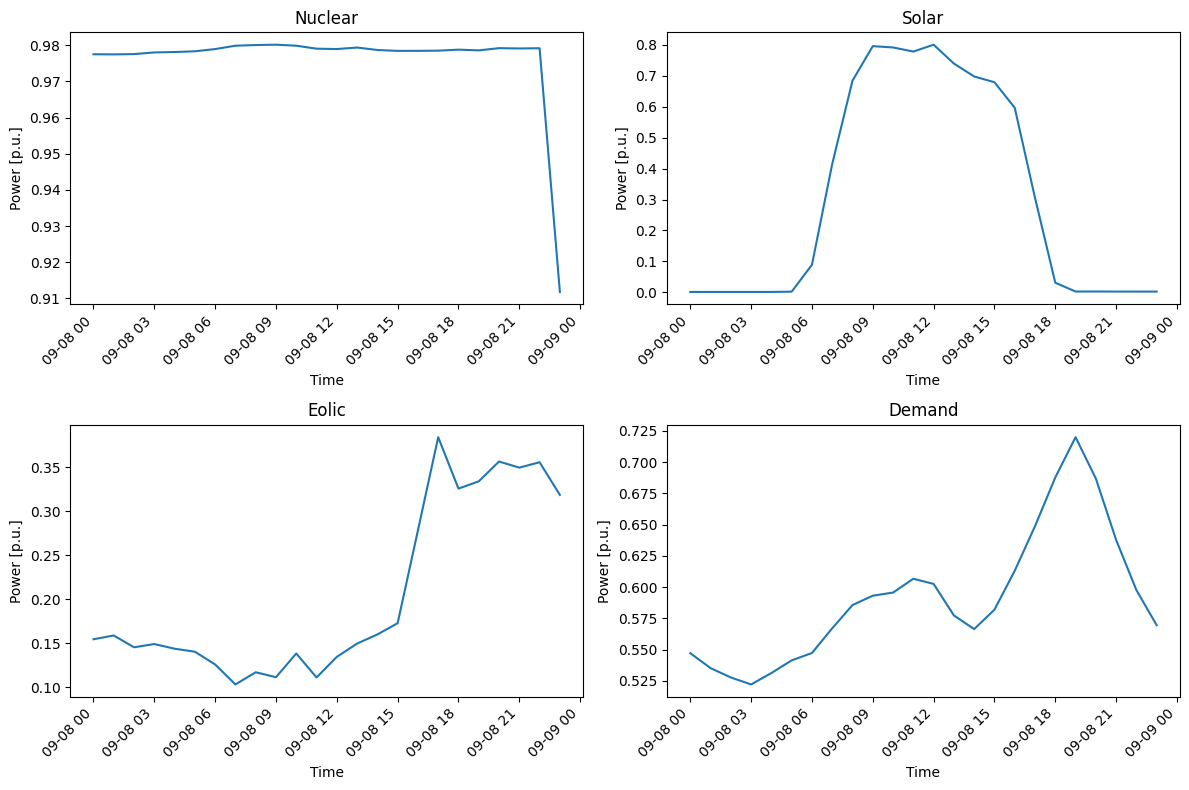

In [4]:
# Basic plot
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))   # 2x2

# Gráfica nuclear
axs[0, 0].plot(dataset["nuclear"])
axs[0, 0].set_title("Nuclear")
axs[0, 0].set_ylabel("Power [p.u.]")
axs[0, 0].set_xlabel("Time")

# Gráfica solar
axs[0, 1].plot(dataset["solar"])
axs[0, 1].set_title("Solar")
axs[0, 1].set_ylabel("Power [p.u.]")
axs[0, 1].set_xlabel("Time")

# Gráfica eólica
axs[1, 0].plot(dataset["eolica"])
axs[1, 0].set_title("Eolic")
axs[1, 0].set_ylabel("Power [p.u.]")
axs[1, 0].set_xlabel("Time")

# Gráfica demanda
axs[1, 1].plot(dataset["demanda"])
axs[1, 1].set_title("Demand")
axs[1, 1].set_ylabel("Power [p.u.]")
axs[1, 1].set_xlabel("Time")

for ax in axs.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()


In [6]:
### Power Flow study ###
# We set the "datasource"; Remember we must provide the profiles in the units used by pandapower, power must be given in MW and MVAR, voltages in p.u. and currents in kA.

# "FrameDataframe"
profiles = pd.DataFrame()
profiles['nuclear_scaled'] = dataset["nuclear"] 
profiles['load_scaled'] = dataset["demanda"]
profiles.reset_index(drop=True, inplace=True)
ds = DFData(profiles)

# ConstControl 
## Load
ConstControl(
    project_net,
    element='load',
    variable='scaling', # Atributo que vamos a controlar (las unidades de lo que sea el profile_name)
    element_index=[0,1,2,3], # indices donde esta este "load" (net.load)
    profile_name=["load_scaled", "load_scaled", "load_scaled", "load_scaled"], # perfil que les asociamos
    data_source = ds
)

## gen
ConstControl(
    project_net,
    element='gen',
    variable='scaling',
    element_index=[0],
    profile_name=["nuclear_scaled"],
    data_source = ds
)

# Simulate and save results
time_steps = ds.df.index
base_dir = os.getcwd()
output_dir = os.path.join(base_dir, "..", "data", "PowerFlow_Results")

ow = OutputWriter(project_net, time_steps, output_path=output_dir, output_file_type=".xlsx", log_variables=list())
ow.log_variable('res_load', 'p_mw')
ow.log_variable('res_sgen', 'p_mw')
ow.log_variable('res_bus', 'vm_pu')
ow.log_variable('res_line', 'loading_percent')
ow.log_variable('res_line', 'i_ka')

run_timeseries(project_net, time_steps=time_steps, run=pp.runpp, numba = False)

100%|██████████| 24/24 [00:01<00:00, 19.40it/s]
